# Advance Algorithm in Machine Learning

## Q2: CNN on MNIST Dataset


Author: Souvik Karmakar & Arif Bin Azhar
Roll No: BIM-2024-25 & BIM-2024-06

In [8]:
import pandas as pd
import numpy as np

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix

### Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)


y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### CNN Model architecture

In [3]:
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    AveragePooling2D(pool_size=(2,2)),
    BatchNormalization(),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(pool_size=(2,2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

### Training model

In [4]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.9574 - loss: 0.1393 - val_accuracy: 0.9831 - val_loss: 0.0531
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.9822 - loss: 0.0590 - val_accuracy: 0.9837 - val_loss: 0.0560
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - accuracy: 0.9868 - loss: 0.0425 - val_accuracy: 0.9839 - val_loss: 0.0644
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 99s 90ms/step - accuracy: 0.9885 - loss: 0.0360 - val_accuracy: 0.9905 - val_loss: 0.0391
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 54ms/step - accuracy: 0.9911 - loss: 0.0301 - val_accuracy: 0.9884 - val_loss: 0.0446
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.9877 - val_loss: 0.0442
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 58s 77ms/step - accuracy: 0.9924 - loss: 0.0233 - val_accuracy: 0.9896 - val_loss: 0.0424
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9930 - loss: 0.0210 - 

### plotting Loss function

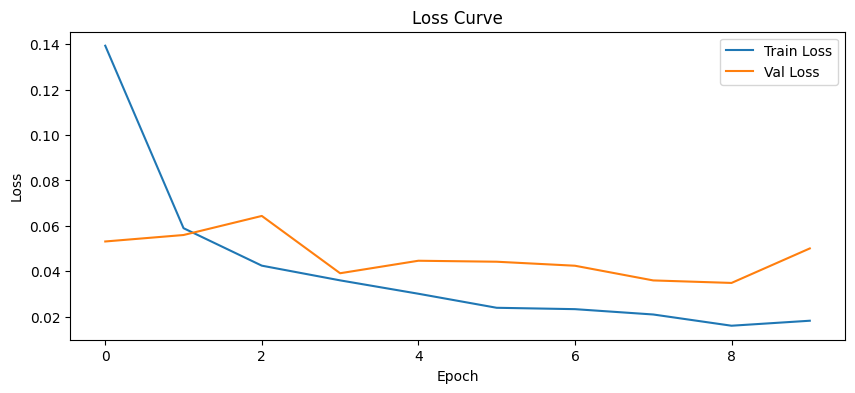

In [5]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



### Plot Accuracy

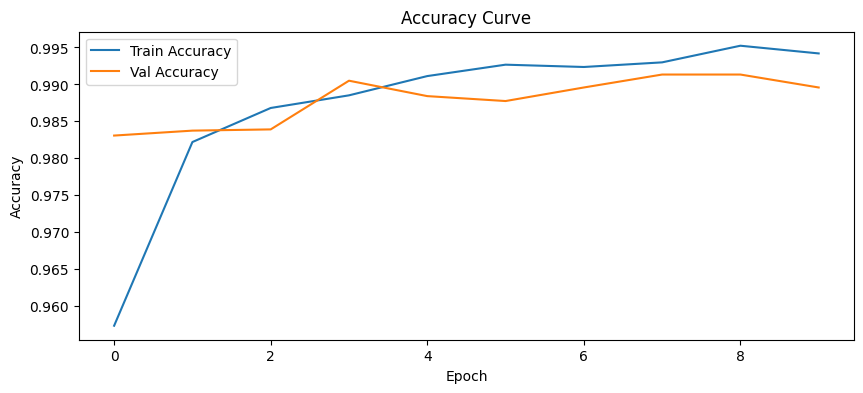

In [6]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Evaluation

In [9]:
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)


cm = confusion_matrix(y_test, y_pred)

print("\nClass-wise Accuracy:")

for i in range(10):
    acc = cm[i,i] / np.sum(cm[i])
    print(f"Digit {i}: {acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Class-wise Accuracy:
Digit 0: 0.9990
Digit 1: 0.9921
Digit 2: 0.9952
Digit 3: 0.9812
Digit 4: 0.9929
Digit 5: 0.9776
Digit 6: 0.9906
Digit 7: 0.9796
Digit 8: 0.9928
Digit 9: 0.9901


### Class-wise F1 Score

In [10]:
f1 = f1_score(y_test, y_pred, average=None)

print("\nClass-wise F1-score:")

for i in range(10):
    print(f"Digit {i}: {f1[i]:.4f}")


Class-wise F1-score:
Digit 0: 0.9899
Digit 1: 0.9934
Digit 2: 0.9894
Digit 3: 0.9851
Digit 4: 0.9914
Digit 5: 0.9864
Digit 6: 0.9927
Digit 7: 0.9868
Digit 8: 0.9933
Digit 9: 0.9833


### Full Classification Report

In [11]:


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

